In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib notebook

In [2]:
df = pd.read_pickle('../IDRome_DB_reanalyzed.pkl')

In [3]:
df

,seq_name,UniProt_ID,N,nu,Rg/nm,Ree/nm,fasta,is_btw_folded,is_nterm,is_cterm,...,first,last,N_FL,protein_name,gene_name,f+,f-,fcr,ncpr,dir_path
0,A0A024RBG1_145_181,A0A024RBG1,37,0.558,1.606731,3.845104,KLGCSPANGNSTVPSLPDNNALFVTAAQTSGLPSSVR,False,False,True,...,145,181,181,Diphosphoinositol polyphosphate phosphohydrola...,NUDT4B,0.027027,0.027027,0.054054,0.000000,A0/A0/24/RBG1/145_181
1,A0A075B6T7_1_32,A0A075B6T7,32,0.525,1.447131,3.385064,MAFWLRSLGLHFRPHLGRRMESFLGGVLLILW,False,True,False,...,1,32,132,T cell receptor alpha variable 6,TRAV6,0.156250,0.031250,0.187500,0.125000,A0/A0/75/B6T7/1_32
2,A0A087WTH1_1_67,A0A087WTH1,67,0.532,2.246105,5.295387,MEDEEKAVEILGNTEAAHPPSPIRCCWLRLRCLAATSIICGCSCLG...,False,True,False,...,1,67,108,Transmembrane protein 265,TMEM265,0.134328,0.149254,0.283582,-0.014925,A0/A0/87/WTH1/1_67
3,A0A087WTH5_1_132,A0A087WTH5,132,0.496,3.038320,7.131916,MPRMILSNTTAVTPFLTKLWQETVQQGGNMSGLARRSPRSGDGKLE...,False,True,True,...,1,132,132,Putative potassium voltage-gated channel subfa...,KCNE1B,0.113636,0.098485,0.212121,0.015152,A0/A0/87/WTH5/1_132
4,A0A087WV53_1_46,A0A087WV53,46,0.567,1.880940,4.603256,MSKAAPAKKPVAVAPAPGCTLDINDPQVQSAAIRIQASYRGHRSRK,False,True,False,...,1,46,238,SPEG neighbor protein,SPEGNB,0.195652,0.043478,0.239130,0.152174,A0/A0/87/WV53/1_46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28053,Q9Y6Z4_1_181,Q9Y6Z4,181,0.493,3.790272,8.597289,MGDIFKNNGVLQGRLRAVACAPHCFGPRLRCLHHDQGLTELAWGTW...,False,True,True,...,1,181,181,Putative uncharacterized protein KIF25-AS1,KIF25-AS1,0.121547,0.060773,0.182320,0.060773,Q9/Y6/Z4/1_181
28054,Q9Y6Z5_1_254,Q9Y6Z5,254,0.528,4.586494,10.810353,MGAAGSDGRCCVRSGRAGTGGAGSKWVVMDLWTGGAGSRRAVLGPD...,False,True,True,...,1,254,254,Putative uncharacterized protein AFDN-DT,AFDN-DT,0.149606,0.035433,0.185039,0.114173,Q9/Y6/Z5/1_254
28055,Q9Y6Z7_1_109,Q9Y6Z7,109,0.546,3.012739,7.121029,MNGFASLLRRNQFILLVLFLLQIQSLGLDIDSRPTAEVCATHTISP...,False,True,False,...,1,109,277,Collectin-10,COLEC10,0.146789,0.128440,0.275229,0.018349,Q9/Y6/Z7/1_109
28056,W6CW81_1_113,W6CW81,113,0.519,2.943975,6.978634,MESKYKEILLLTSLDNITDEELDRFKCFLPDEFNIATGKLHTLNST...,False,True,True,...,1,113,113,Pyrin domain-containing protein 5,PYDC5,0.123894,0.150442,0.274336,-0.026549,W6/CW/81/1_113


In [14]:
# Assign categories using apply
df['category'] = df.apply(
    lambda row: 1 if row['fcr'] < 0.25 and np.abs(row['ncpr']) < 0.25 else
                2 if 0.25 <= row['fcr'] <= 0.35 and np.abs(row['ncpr']) <= 0.35 else
                3 if row['fcr'] > 0.35 and np.abs(row['ncpr']) <= 0.35 else
                4 if row['fcr'] > 0.35 and np.abs(row['ncpr']) > 0.35 else
                -1,
    axis=1
)

In [7]:
df

,seq_name,UniProt_ID,N,nu,Rg/nm,Ree/nm,fasta,is_btw_folded,is_nterm,is_cterm,...,last,N_FL,protein_name,gene_name,f+,f-,fcr,ncpr,dir_path,category
0,A0A024RBG1_145_181,A0A024RBG1,37,0.558,1.606731,3.845104,KLGCSPANGNSTVPSLPDNNALFVTAAQTSGLPSSVR,False,False,True,...,181,181,Diphosphoinositol polyphosphate phosphohydrola...,NUDT4B,0.027027,0.027027,0.054054,0.000000,A0/A0/24/RBG1/145_181,1
1,A0A075B6T7_1_32,A0A075B6T7,32,0.525,1.447131,3.385064,MAFWLRSLGLHFRPHLGRRMESFLGGVLLILW,False,True,False,...,32,132,T cell receptor alpha variable 6,TRAV6,0.156250,0.031250,0.187500,0.125000,A0/A0/75/B6T7/1_32,1
2,A0A087WTH1_1_67,A0A087WTH1,67,0.532,2.246105,5.295387,MEDEEKAVEILGNTEAAHPPSPIRCCWLRLRCLAATSIICGCSCLG...,False,True,False,...,67,108,Transmembrane protein 265,TMEM265,0.134328,0.149254,0.283582,-0.014925,A0/A0/87/WTH1/1_67,2
3,A0A087WTH5_1_132,A0A087WTH5,132,0.496,3.038320,7.131916,MPRMILSNTTAVTPFLTKLWQETVQQGGNMSGLARRSPRSGDGKLE...,False,True,True,...,132,132,Putative potassium voltage-gated channel subfa...,KCNE1B,0.113636,0.098485,0.212121,0.015152,A0/A0/87/WTH5/1_132,1
4,A0A087WV53_1_46,A0A087WV53,46,0.567,1.880940,4.603256,MSKAAPAKKPVAVAPAPGCTLDINDPQVQSAAIRIQASYRGHRSRK,False,True,False,...,46,238,SPEG neighbor protein,SPEGNB,0.195652,0.043478,0.239130,0.152174,A0/A0/87/WV53/1_46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28053,Q9Y6Z4_1_181,Q9Y6Z4,181,0.493,3.790272,8.597289,MGDIFKNNGVLQGRLRAVACAPHCFGPRLRCLHHDQGLTELAWGTW...,False,True,True,...,181,181,Putative uncharacterized protein KIF25-AS1,KIF25-AS1,0.121547,0.060773,0.182320,0.060773,Q9/Y6/Z4/1_181,1
28054,Q9Y6Z5_1_254,Q9Y6Z5,254,0.528,4.586494,10.810353,MGAAGSDGRCCVRSGRAGTGGAGSKWVVMDLWTGGAGSRRAVLGPD...,False,True,True,...,254,254,Putative uncharacterized protein AFDN-DT,AFDN-DT,0.149606,0.035433,0.185039,0.114173,Q9/Y6/Z5/1_254,1
28055,Q9Y6Z7_1_109,Q9Y6Z7,109,0.546,3.012739,7.121029,MNGFASLLRRNQFILLVLFLLQIQSLGLDIDSRPTAEVCATHTISP...,False,True,False,...,109,277,Collectin-10,COLEC10,0.146789,0.128440,0.275229,0.018349,Q9/Y6/Z7/1_109,2
28056,W6CW81_1_113,W6CW81,113,0.519,2.943975,6.978634,MESKYKEILLLTSLDNITDEELDRFKCFLPDEFNIATGKLHTLNST...,False,True,True,...,113,113,Pyrin domain-containing protein 5,PYDC5,0.123894,0.150442,0.274336,-0.026549,W6/CW/81/1_113,2


In [15]:
df[df['category']==4]

,seq_name,UniProt_ID,N,nu,Rg/nm,Ree/nm,fasta,is_btw_folded,is_nterm,is_cterm,...,last,N_FL,protein_name,gene_name,f+,f-,fcr,ncpr,dir_path,category
151,A0A494C086_275_341,A0A494C086,67,0.634,2.876960,7.307668,GKTRSRIPLLRKRWFQLGRSMNPRARKNRSRIPLLRKRRFQLGRSM...,False,False,False,...,341,402,Putative speedy protein E21,SPDYE21,0.388060,0.000000,0.388060,0.388060,A0/A4/94/C086/275_341,4
228,A1L162_127_156,A1L162,30,0.670,1.680408,4.434263,NSDEDSSGESKGESDEELSDESSDEGEDGS,False,False,True,...,156,156,Glutamate-rich protein 2,ERICH2,0.033333,0.500000,0.533333,-0.466667,A1/L1/62/127_156,4
652,A6NIY4_279_342,A6NIY4,64,0.620,2.806667,7.025959,SRIPLLRKRWFQLGRSMNPRARKKRSRIPLLRKRRFQLGRSMNPRA...,False,False,False,...,342,402,Speedy protein E5,SPDYE5,0.390625,0.000000,0.390625,0.390625,A6/NI/Y4/279_342,4
1060,B2RPK0_164_211,B2RPK0,48,0.289,1.652060,3.426710,AKGKPEAAKKGVVKAEKSKKKKEEEEDEEDEEDEEEEDEEDEEDDDDE,False,False,True,...,211,211,Putative high mobility group protein B1-like 1,HMGB1P1,0.208333,0.583333,0.791667,-0.395833,B2/RP/K0/164_211,4
1600,O14602_114_144,O14602,31,0.667,1.760443,4.564665,KINETDTFGPGDDDEIQFDDIGDDDEDIDDI,False,False,True,...,144,144,"Eukaryotic translation initiation factor 1A, Y...",EIF1AY,0.032258,0.516129,0.548387,-0.483871,O1/46/02/114_144,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26455,Q9UKY1_828_873,Q9UKY1,46,0.509,1.946305,4.668347,GIELFEENEEEDEVIDDQEEDEEETDDSDTWEPPRHVKRKLSKSDD,False,False,True,...,873,873,Zinc fingers and homeoboxes protein 1,ZHX1,0.108696,0.478261,0.586957,-0.391304,Q9/UK/Y1/828_873,4
26591,Q9ULJ8_617_672,Q9ULJ8,56,0.643,2.605948,6.591713,LEQHYAQYDADDDETGEYATDEEEDEVGPVLPGSDMAIEVFELPEN...,True,False,False,...,672,1098,Neurabin-1,PPP1R9A,0.000000,0.375000,0.375000,-0.375000,Q9/UL/J8/617_672,4
26672,Q9ULW3_1_39,Q9ULW3,39,0.630,1.992885,5.021713,MEAEESEKAATEQEPLEGTEQTLDAEEEQEESEEAACGS,False,True,False,...,39,272,Activator of basal transcription 1,ABT1,0.051282,0.410256,0.461538,-0.358974,Q9/UL/W3/1_39,4
26675,Q9ULW6_167_237,Q9ULW6,71,0.649,3.287336,8.459514,EYKSDSEDCDDEEMCHEEMYGNEEGMVHEYVDEDDGYEDYYYDYAV...,False,False,False,...,237,460,Nucleosome assembly protein 1-like 2,NAP1L2,0.028169,0.535211,0.563380,-0.507042,Q9/UL/W6/167_237,4


In [10]:
# Matplotlib settings for publication-quality plots
base_fontsize = 16
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})


<IPython.core.display.Javascript object>


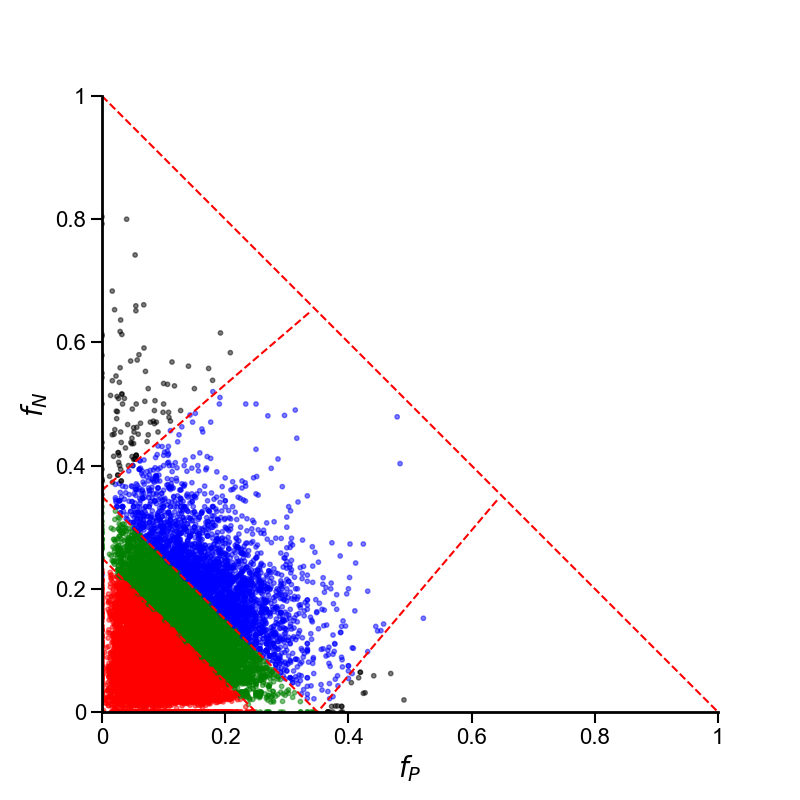

/var/folders/1f/m8_t8g414dz2d33zlncf3gv40000gn/T/ipykernel_89121/2555235175.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=base_fontsize + 2, loc='upper right', frameon=False)


In [50]:
# Panel (c) Data Preparation
x = np.linspace(0, 1, 200)
line_x = np.linspace(0, 1, 200)  # Line data
line_y_1 = 1.18 * line_x - 1.18 * 0.35
line_y_1_masked = np.where(line_y_1 < 0.35, line_y_1, np.nan)
line_y_2 = 6/7 * line_x + 0.36
line_y_2_masked = np.where(line_y_2 < 0.65, line_y_2, np.nan)
line_y_3 = -line_x + 1
line_y_4 = -line_x + 0.35
line_y_5 = -line_x + 0.25
colors = ['red', 'green', 'blue', 'black']
fig, ax1 = plt.subplots(figsize=(8,8))
ax1.plot(line_x, line_y_1_masked, color='red', linestyle='--', linewidth=1.5)
ax1.plot(line_x, line_y_2_masked, color='red', linestyle='--', linewidth=1.5)
ax1.plot(line_x, line_y_3, color='red', linestyle='--', linewidth=1.5)
ax1.plot(line_x, line_y_4, color='red', linestyle='--', linewidth=1.5)
ax1.plot(line_x, line_y_5, color='red', linestyle='--', linewidth=1.5)
# Map categories to colors for scatter plot
scatter_colors = df['category'].map(lambda cat: colors[cat - 1])  # Assuming categories are 1-indexed
ax1.scatter(df['f+'], df['f-'], s=10, alpha=0.5, c=scatter_colors)

ax1.set_xlabel('$f_{P}$', fontsize=base_fontsize+4)
ax1.set_ylabel('$f_{N}$', fontsize=base_fontsize+4)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# yticks
general_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]  # Tick positions
general_ticklabels = ['0', '0.2', '0.4', '0.6', '0.8', '1']  # Only show labels for 0, 0.5, and 1
ax1.set_yticks(general_ticks)
ax1.set_yticklabels(general_ticklabels)
ax1.set_xticks(general_ticks)
ax1.set_xticklabels(general_ticklabels)
ax1.tick_params(labelsize=base_fontsize, length=8, width=1.5)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)
ax1.set_aspect('equal', adjustable='box')
ax1.legend(fontsize=base_fontsize + 2, loc='upper right', frameon=False)
plt.savefig(f'IDRome_assign_DOS.png', dpi=600, bbox_inches='tight')

In [27]:
7/6

1.1666666666666667

In [35]:
6/7

0.8571428571428571

In [49]:
100*135/28058

0.4811461971630195